In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import os

# Measuring the "time of arrival" of a pulsar
## Crab Pulsar Experiment Part 3.2

This notebook can be used for the first part of the crab timing part of the experiment. Here you will find code that reads your data files (pulsar archives) and matches the observed pulse against a _standard template_ of the crab pulsar. This standard template is a noise-free model of the shape of the pulse and we can measure the time that the pulse arrived to very high precision by correlating the known shape of the pulse (the template) with the noisy data.

The code is in four main parts:
 1. Specifying the data location
 2. Dedispersion of the data ( **insert your code from Part 1 here** )
 3. Measuring the time of arrival (ToA)
 4. Visualising the result
 
_You will need to run all three parts in sequence to get the right results._ Visualising the output is important to be sure you have got sensible results.



# Organizing the Code

This notebook has been reorganized to improve clarity and usability. The following sections are included:

1. **File Configuration**: Specify the input file and output file names, including observation date and time.
2. **Data Loading**: Load the pulsar data and template file.
3. **Dedispersion**: Perform dedispersion on the loaded data.
4. **Time of Arrival (ToA) Calculation**: Compute the ToAs using the provided functions.
5. **Saving Results**: Save the computed ToAs to a specified output file.

Make sure to follow the sequence of the sections for proper execution.

# Load Data

# File Configuration

Specify the input file and output file names below. The observation date and time will be extracted from the input file name and used to generate the output file name.

In [30]:
# File Configuration
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Specify the pulsar name and observation date/time
pulsar_name = "B0531+21"
obs_datetime_str = "20260303_113724"  # Format: YYYYMMDD_HHMMSS

# Generate input and output file names based on the pulsar name and observation date/time
filename = f"/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/{pulsar_name}/{obs_datetime_str}_{pulsar_name}.npz"
output_file = f"/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/toas/toa/{pulsar_name}_{obs_datetime_str}_toas.txt"

#templatefilename=f"/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/ASCIItemplates/template_{pulsar_name}_1024bin.txt"# Enter the filename of your data here
templatefilename=f"/Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/other/template.txt"

# Load the data
obsdata = np.load(filename, allow_pickle=True)
print(obsdata['header'])
data = obsdata['data']
print("'Guess Period':", obsdata['approx_period'])

Filename                      : 20260303_113724_B0531+21.clng
Source Name                   : B0531+21
Number of channels            : 40
Number of phase bins          : 1024
Number of sub-integrations    : 91
Centre Freq (MHz)             : 611.0
Bandwidth (MHz)               : 10.0
Integration Time (s)          : 18148.999708
Telescope                     : Jodrell
'Guess Period': 0.033851894


In [31]:
obsdata = np.load(filename, allow_pickle=True)
print(obsdata['header'])
data=obsdata['data']

print("'Guess Period':",obsdata['approx_period'])

Filename                      : 20260303_113724_B0531+21.clng
Source Name                   : B0531+21
Number of channels            : 40
Number of phase bins          : 1024
Number of sub-integrations    : 91
Centre Freq (MHz)             : 611.0
Bandwidth (MHz)               : 10.0
Integration Time (s)          : 18148.999708
Telescope                     : Jodrell
'Guess Period': 0.033851894


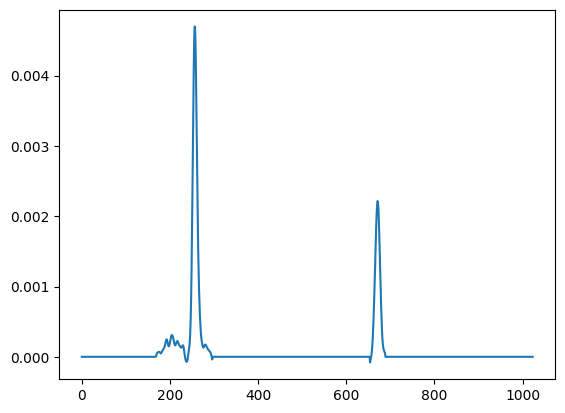

In [32]:

template=np.loadtxt(templatefilename)
plt.plot(template)
plt.show()

In [33]:
##
#  This function will shift each row of a 2-d (3-d) array by the the number of columns specified in the "shifts" array.
#  data_in - the 2-d (3-d) array to work on
#  shifts - the shifts to apply
#  Returns: The shifted array
##
def shift_rows(data_in, shifts):
    shifted = np.zeros_like(data_in)
    if data_in.ndim == 3:
        for i in range(data_in.shape[0]):
            shifted[i] = shift_rows(data_in[i],shifts)
    else:
        for i in range(data_in.shape[0]):
            shifted[i] = np.roll(data_in[i],int(shifts[i]))
    return shifted


## Computing the time of arrivals
**Please don't worry too much about how this code works.** This is based on research software used for experiments ranging searching for planets around pulsars to measuring gravitational waves passing over the earth. It has been annotated with a few comments for the curious, but you can mostly just treat this as a black box you can use to get time of arrival measurements for your pulsar data.
If you are desparate to dig into the details, this code is based on the ToA estimation procedure described in Appendix A of Taylor et al. 1992. (https://www.jstor.org/stable/53915)

In [34]:

def get_toas(ddfreq_averaged,obsdata,plots=True):
    
    times=obsdata['times'] # The time of phase zero for each subint
    approx_period=obsdata['approx_period'] # The approximate period of the pulsar
    toas=[]
    toa_errs=[]
    tempo2_toas=[]

    # Equation A7 in Taylor 1992
    def get_dchi(tau,N,nbin):
        dphi = np.angle(xspec)[1:N]

        k=np.arange(1,N)

        dchi = np.sum(k*np.abs(f_prof[1:N])*np.abs(f_template[1:N]) * np.sin(dphi + 2*np.pi*k*tau/nbin))
        return dchi


    # Equation A9 in Taylor 1992
    def get_b(tau,N,nbin):
        dphi = np.angle(xspec)[1:N]
        k=np.arange(1,N)
        scale = np.sum(np.abs(f_prof[1:N])*np.abs(f_template[1:N]) * np.cos(dphi + 2*np.pi*k*tau/nbin))
        scale /= np.sum(np.abs(f_template[1:N])**2)
        return scale


    # Equation A10 in Taylor 1992
    def get_sigma_tau(tau,N,nbin,b):
        dphi = np.angle(xspec)[1:N]
        k=np.arange(1,N)
        chi2=np.sum(np.abs(f_prof[1:N])**2 + b**2*np.abs(f_template[1:N]) )-2*b*np.sum(np.abs(f_prof[1:N])*np.abs(f_template[1:N]) * np.cos(dphi + 2*np.pi*k*tau/nbin))
        sigma2 = chi2/(N-1)
        de = np.sum((k**2) * np.abs(f_prof[1:N])*np.abs(f_template[1:N]) * np.cos(dphi + 2*np.pi*k*tau/nbin))
        fac=nbin/(2*np.pi)
        return np.sqrt(sigma2/(2*b*de))*fac

    # Just for plotting, rotates an array by a fractional phase shift using Fourier transform
    def rotate_phs(ff,phase_shift):
        fr = ff*np.exp(-1.0j*2*np.pi*np.arange(len(ff))*phase_shift)
        return np.fft.irfft(fr)

    
    # Loop over every sub integration
    for ip in range(len(ddfreq_averaged)):
        try:
            prof=ddfreq_averaged[ip]
            nbin=len(prof)

            # We are going to do a cross correlation by means of the Fourier transform and the Wiener-Kinchin theorem
            f_template = np.fft.rfft(template)
            f_prof = np.fft.rfft(prof)

            # The cross correlation of a and b is the inverse transform of FT(a) times the conjugate of FT(b)
            xspec= f_template.conj() * f_prof # "cross spectrum"
            xcor = np.fft.irfft(xspec) # Cross correlation

            ishift = np.argmax(np.abs(xcor)) # estimate of the shift directly from the peak cross-correlation

            # We need to define some bounds to search. (Actually this might not be optimal)
            lo=ishift-1
            hi=ishift+1
            nh=len(xspec)
            # We minimise the chisquare parameter by findng the root of it's derivatiive following Taylor 1992 
            # This root_scalar method uses the 'Brent 1973' algorithm for root finding.
            ret = opt.root_scalar(get_dchi,bracket=(lo,hi),x0=ishift,args=(nh,nbin),method='brentq')

            # tau is the bin shift between data and template, which will become our ToA
            tau=ret.root
            # Again folow the math of Taylor 1992 to get the scale factor, which it calls 'b'
            scale=get_b(tau,nh,nbin)
            # And finally given the shift and scale we can find the uncertainty on the shift.
            sigma_tau=get_sigma_tau(tau,nh,nbin,scale)

            # Phase shift is bin shift divided by nbins
            phase_shift = tau/nbin

            # ToA is the phase shift converted to a time shift and added to the time of phase zero.
            toa = times[ip] + approx_period*tau/nbin/86400.0
            toa_err = approx_period*sigma_tau/nbin
            tempo2_toa=" test 611 {:.16f} {} jb42\n".format(toa,toa_err*1e6)

            toas.append(toa)
            toa_errs.append(toa_err)
            tempo2_toas.append(tempo2_toa)

            phase=np.linspace(0,1,nbin)

            rotate_and_scaled_template=scale*rotate_phs(f_template,phase_shift)
            diff=prof-rotate_and_scaled_template

            d= np.amax(prof)-np.amin(prof)
            if plots:
                # And do some plotting...
                plt.figure(figsize=(12,8))
                plt.xlabel("Pulse Phase")
                plt.ylabel("Flux Density (arbitrary)")

                plt.title(r"{} Profile {:d}:  $\delta t =$ {:.3f} $\pm$ {:.3f} ms".format(obsdata['source_name'],ip,1e3*approx_period*phase_shift,1e3*toa_err))
                plt.step(phase,prof,color='black',linewidth=1.0,label="Data")
                plt.plot(phase,rotate_and_scaled_template,color='red',label="Template")

                plt.step(phase,diff-d,color='green',linewidth=1.0,alpha=0.8,label=r"Data$-$template")
                plt.axhline(-d,ls=":",color='k')

                plt.xlim(0,1)
                plt.ylim(np.amin(prof)-1.2*d,np.amax(prof)+0.1*d)

                plt.legend(loc="lower left",ncol=3)

                plt.show()
                plt.close()
        except ValueError as e:
            print(e)
    return np.array(toas),np.array(toa_errs),tempo2_toas


# Your code - Dedisperse and make the ToAs
Here you can insert your dedispersion code from part 1, and then call the function to make toas

data shape: (91, 40, 1024)
freqs shape: (40,)
Period (s): 0.033851894
time_averaged shape: (40, 1024)

--- SINGLE DM SCAN ---
DM range: 0 to 3000 step 0.5
Best DM (raw score): 56.0000


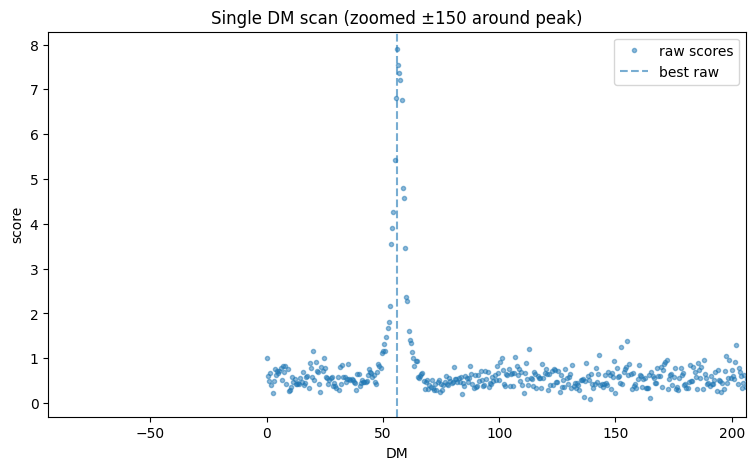


FINAL DM = 56.0


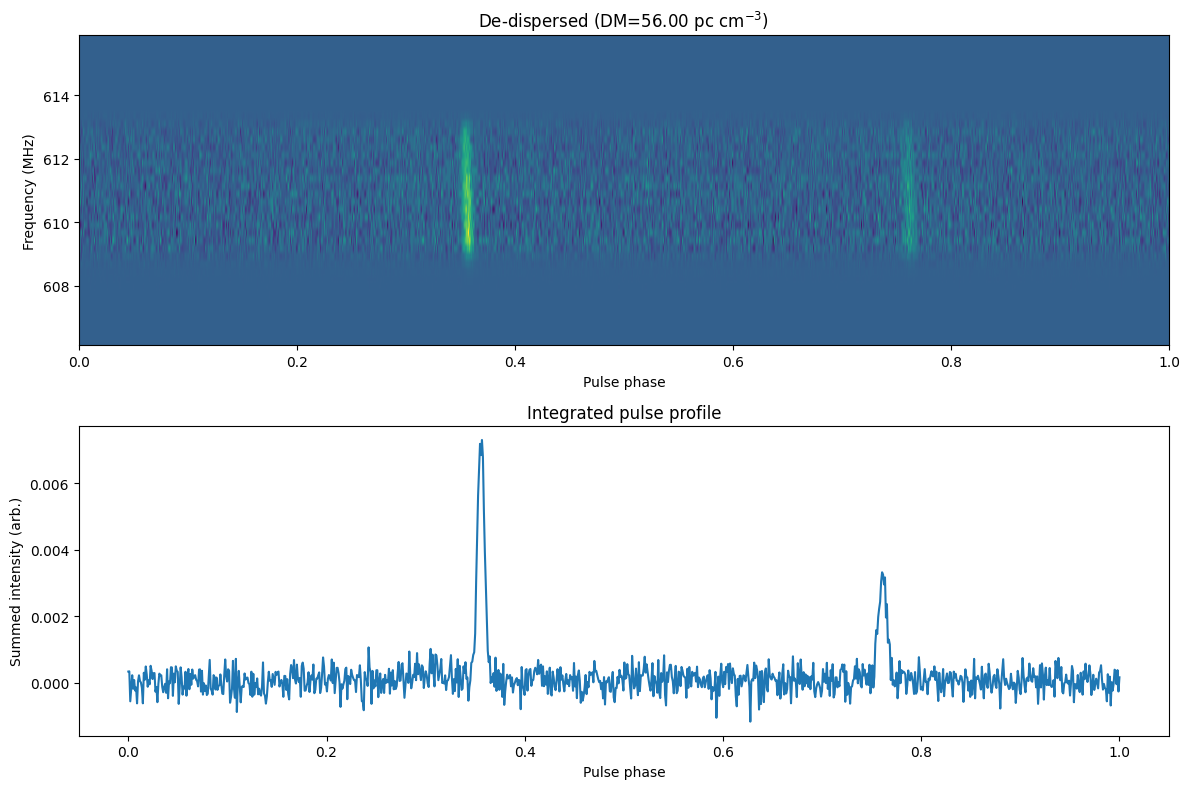

In [35]:
import numpy as np
import matplotlib.pyplot as plt

data = obsdata["data"]      
freqs = obsdata["freqs"]
P = float(obsdata["approx_period"])  

print("data shape:", data.shape)
print("freqs shape:", freqs.shape)
print("Period (s):", P)


time_averaged = np.mean(data, axis=0)
nchan, nphase = time_averaged.shape
print("time_averaged shape:", time_averaged.shape)

K_DM = 4.148808e3  # seconds * MHz^2 * (pc cm^-3)^-1

def dm_to_bin_shifts(dm, freqs_mhz, P_sec, nphase, nu_ref_mhz=None):
    freqs_mhz = np.asarray(freqs_mhz, dtype=float)
    if nu_ref_mhz is None:
        nu_ref_mhz = float(np.max(freqs_mhz))

    # delay in SECONDS (relative to nu_ref)
    dt_s = K_DM * dm * (freqs_mhz**(-2) - nu_ref_mhz**(-2))

    # convert delay -> phase bins
    bins = (dt_s / P_sec) * nphase

    # remove the delay
    return -bins

def dedisperse_at_dm(dm):
    shifts = dm_to_bin_shifts(dm, freqs, P, nphase)
    ded = shift_rows(time_averaged, shifts)      
    prof = np.sum(ded, axis=0)                   
    return ded, prof

# ============================================================
# USER SETTINGS 
# ============================================================

DM_MIN = 0
DM_MAX = 3000    

DM_STEP = 0.5 



SKIP_RANGES = []


def dm_score(ded, prof):
    """
    Robust DM score:
      - SNR: (peak - baseline)/noise
      - channel support: how many channels are significantly 'on' at the peak phase
      - sharpness penalty: divide by pulse width above a threshold
    Returns a single scalar score (higher is better).
    """
    baseline = np.median(prof)
    noise = np.std(prof)
    if noise == 0:
        return 0.0

    snr = (np.max(prof) - baseline) / noise
    peak = int(np.argmax(prof))

    # Channel-coherence check at the pulse peak phase bin
    channel_values = ded[:, peak]
    ded_med = np.median(ded)
    ded_std = np.std(ded)
    if ded_std == 0:
        return 0.0
    chan_strength = np.sum(channel_values > (ded_med + 2 * ded_std))

    # Pulse width in phase bins (penalise smearing)
    width = np.sum(prof > (baseline + 2 * noise))
    if width == 0:
        return 0.0

    return snr * chan_strength / width

def scan_dm_grid(dms):
    """
    Scan a list/array of DMs and return (best_dm, best_score, scores_array).
    """
    dms = np.asarray(dms, dtype=float)
    scores = np.zeros_like(dms, dtype=float)

    for i, dm in enumerate(dms):
        ded, prof = dedisperse_at_dm(dm)
        scores[i] = dm_score(ded, prof)

    best_i = int(np.argmax(scores))
    return float(dms[best_i]), float(scores[best_i]), scores



def remove_skipped_ranges(dms, skip_ranges):
    """
    Remove DM values that fall inside any excluded interval.
    skip_ranges = [(min1,max1), (min2,max2), ...]
    """
    dms = np.asarray(dms, dtype=float)

    if not skip_ranges:
        return dms

    mask = np.ones_like(dms, dtype=bool)

    for lo, hi in skip_ranges:
        mask &= ~((dms >= lo) & (dms <= hi))

    return dms[mask]


def scan_dm_range(dms):

    dms = remove_skipped_ranges(dms, SKIP_RANGES)

    if len(dms) == 0:
        raise ValueError("All DM values were removed by SKIP_RANGES.")

    scores = []

    for dm in dms:
        ded, prof = dedisperse_at_dm(dm)
        scores.append(dm_score(ded, prof))

    scores = np.array(scores)
    best_index = np.argmax(scores)

    return dms[best_index], scores



def dm_single_search(do_plot=True):

    print("\n--- SINGLE DM SCAN ---")

    ZOOM_WIDTH = 150   # show ±2 DM around the peak

    # Build DM grid
    dms = np.arange(DM_MIN, DM_MAX + DM_STEP, DM_STEP)

    # Optional if you use skip ranges elsewhere
    # dms = remove_skipped_ranges(dms, SKIP_RANGES)

    # Scan scores
    best_dm, scores = scan_dm_range(dms)

    scores = np.asarray(scores)
    best_i_raw = int(np.argmax(scores))
    peak_dm = float(dms[best_i_raw])

    print(f"DM range: {DM_MIN} to {DM_MAX} step {DM_STEP}")
    print(f"Best DM (raw score): {peak_dm:.4f}")

    # -------- Plot --------
    if do_plot:

        plt.figure(figsize=(9,5))
        plt.plot(dms, scores, '.', alpha=0.5, label="raw scores")
        plt.axvline(peak_dm, linestyle='--', alpha=0.6, label="best raw")

        # zoom around peak
        plt.xlim(peak_dm - ZOOM_WIDTH, peak_dm + ZOOM_WIDTH)

        plt.xlabel("DM")
        plt.ylabel("score")
        plt.title(f"Single DM scan (zoomed ±{ZOOM_WIDTH} around peak)")
        plt.legend()
        plt.show()

    return peak_dm, dms, scores
# ============================================================
# RUN SEARCH
# ============================================================
best_dm, dms, scores = dm_single_search()

print("\nFINAL DM =", best_dm)



ded, prof = dedisperse_at_dm(best_dm)

phase = np.linspace(0, 1, nphase)

plt.figure(figsize=(12, 8))

plt.subplot(211)
plt.imshow(ded, aspect="auto", origin="lower",
           extent=(0, 1, freqs[0], freqs[-1]))
plt.xlabel("Pulse phase")
plt.ylabel("Frequency (MHz)")
plt.title(f"De-dispersed (DM={best_dm:.2f} pc cm$^{{-3}}$)")

plt.subplot(212)
plt.plot(phase, prof)
plt.xlabel("Pulse phase")
plt.ylabel("Summed intensity (arb.)")
plt.title("Integrated pulse profile")

plt.tight_layout()
plt.show()

In [36]:
import numpy as np

# data: (nsub, nchan, nphase)
data  = obsdata["data"]
freqs = np.asarray(obsdata["freqs"], dtype=float)
P     = float(obsdata["approx_period"])

nsub, nchan, nphase = data.shape

# ---- compute bin shifts (same for all subints) ----
shifts = dm_to_bin_shifts(best_dm, freqs, P, nphase)   # length nchan

# ---- de-disperse each subint and frequency-average ----
ddfreq_averaged = np.zeros((nsub, nphase), dtype=float)

for isub in range(nsub):
    # dedisperse this subint: input shape (nchan, nphase)
    ded_sub = shift_rows(data[isub, :, :], shifts)  # uses your existing shift_rows()

    # frequency-average (sum over channels) -> shape (nphase,)
    ddfreq_averaged[isub, :] = np.sum(ded_sub, axis=0)

print("ddfreq_averaged shape:", ddfreq_averaged.shape)  # should be (nsub, nphase)

ddfreq_averaged shape: (91, 1024)


In [37]:
## Insert your de-dispersion code here
# ... 
# Create a de-dispersed frequency-averaged data called ddfreq_averaged
# ddfreq_averaged = 
#
nsub, nchan,nphase = data.shape
ichan=np.arange(nchan)

toas, toa_errs, extra = get_toas(ddfreq_averaged, obsdata, False)

with open(filename+".toas.txt","w") as outf:
    for t,e in zip(toas,toa_errs):
        print("{:.18f} {:.3g}".format(t,e))
        outf.write("{:.18f} {:.3g}\n".format(t,e))

61102.485995025155716576 8.61e-05
61102.487731292269018013 3.76e-05
61102.490045919359545223 3.95e-05
61102.492360938158526551 4.2e-05
61102.494675565736542922 3.79e-05
61102.496990583364095073 4.69e-05
61102.499189617279625963 4.32e-05
61102.501620188893866725 nan
61102.504282423622498754 4.13e-05
61102.506249876445508562 4.57e-05
61102.508564503274101298 3.62e-05
61102.510879522342293058 3.67e-05
61102.513194541475968435 3.78e-05
61102.515508776654314715 3.7e-05
61102.517823794936703052 4.13e-05
61102.520138422129093669 4.21e-05
61102.522453833684267011 3.59e-05
61102.524768068535195198 3.39e-05
61102.527083087195933331 3.53e-05
61102.529398105951258913 4.21e-05
61102.531712693933513947 7.65e-05
61102.534027360765321646 3.44e-05
61102.536342771418276243 3.24e-05
61102.538657006261928473 3.77e-05
61102.540046095244179014 4.76e-05
61102.544328568183118477 4.07e-05
61102.545601671816257294 3.37e-05
61102.547916299030475784 4.45e-05
61102.550231318076839671 4.1e-05
61102.5525459446798777

/var/folders/6f/my8vvz3j25345wq6n05616cm0000gn/T/ipykernel_66470/963361225.py:36: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(sigma2/(2*b*de))*fac


In [38]:
out = get_toas(ddfreq_averaged, obsdata, False)
print("Returned type:", type(out))
if isinstance(out, (tuple, list)):
    print("Returned items:", len(out))
    for i, item in enumerate(out):
        print(i, type(item), np.shape(item) if hasattr(item, "shape") else "")

Returned type: <class 'tuple'>
Returned items: 3
0 <class 'numpy.ndarray'> (91,)
1 <class 'numpy.ndarray'> (91,)
2 <class 'list'> 


/var/folders/6f/my8vvz3j25345wq6n05616cm0000gn/T/ipykernel_66470/963361225.py:36: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(sigma2/(2*b*de))*fac


In [39]:
# Save the computed ToAs to the output file
with open(output_file, "w") as f:
    f.write("# ToAs for B0531+21\n")
    f.write("# Column 1: MJD (days)\n")
    f.write("# Column 2: Uncertainty (seconds)\n\n")
    for t, e in zip(toas, toa_errs):
        f.write("{:.18f} {:.6e}\n".format(t, e))
print("ToAs written to:", output_file)

ToAs written to: /Users/alismk/Desktop/3rdYear Courses/Sem2/Lab/Obs/toas/toa/B0531+21_20260303_113724_toas.txt
